Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Computed b for station S2N17
Computed b for station S2N18
Computed b for station S4N06
Computed b for station S4N11
Computed b for station S4N25
Computed b for station S6N08


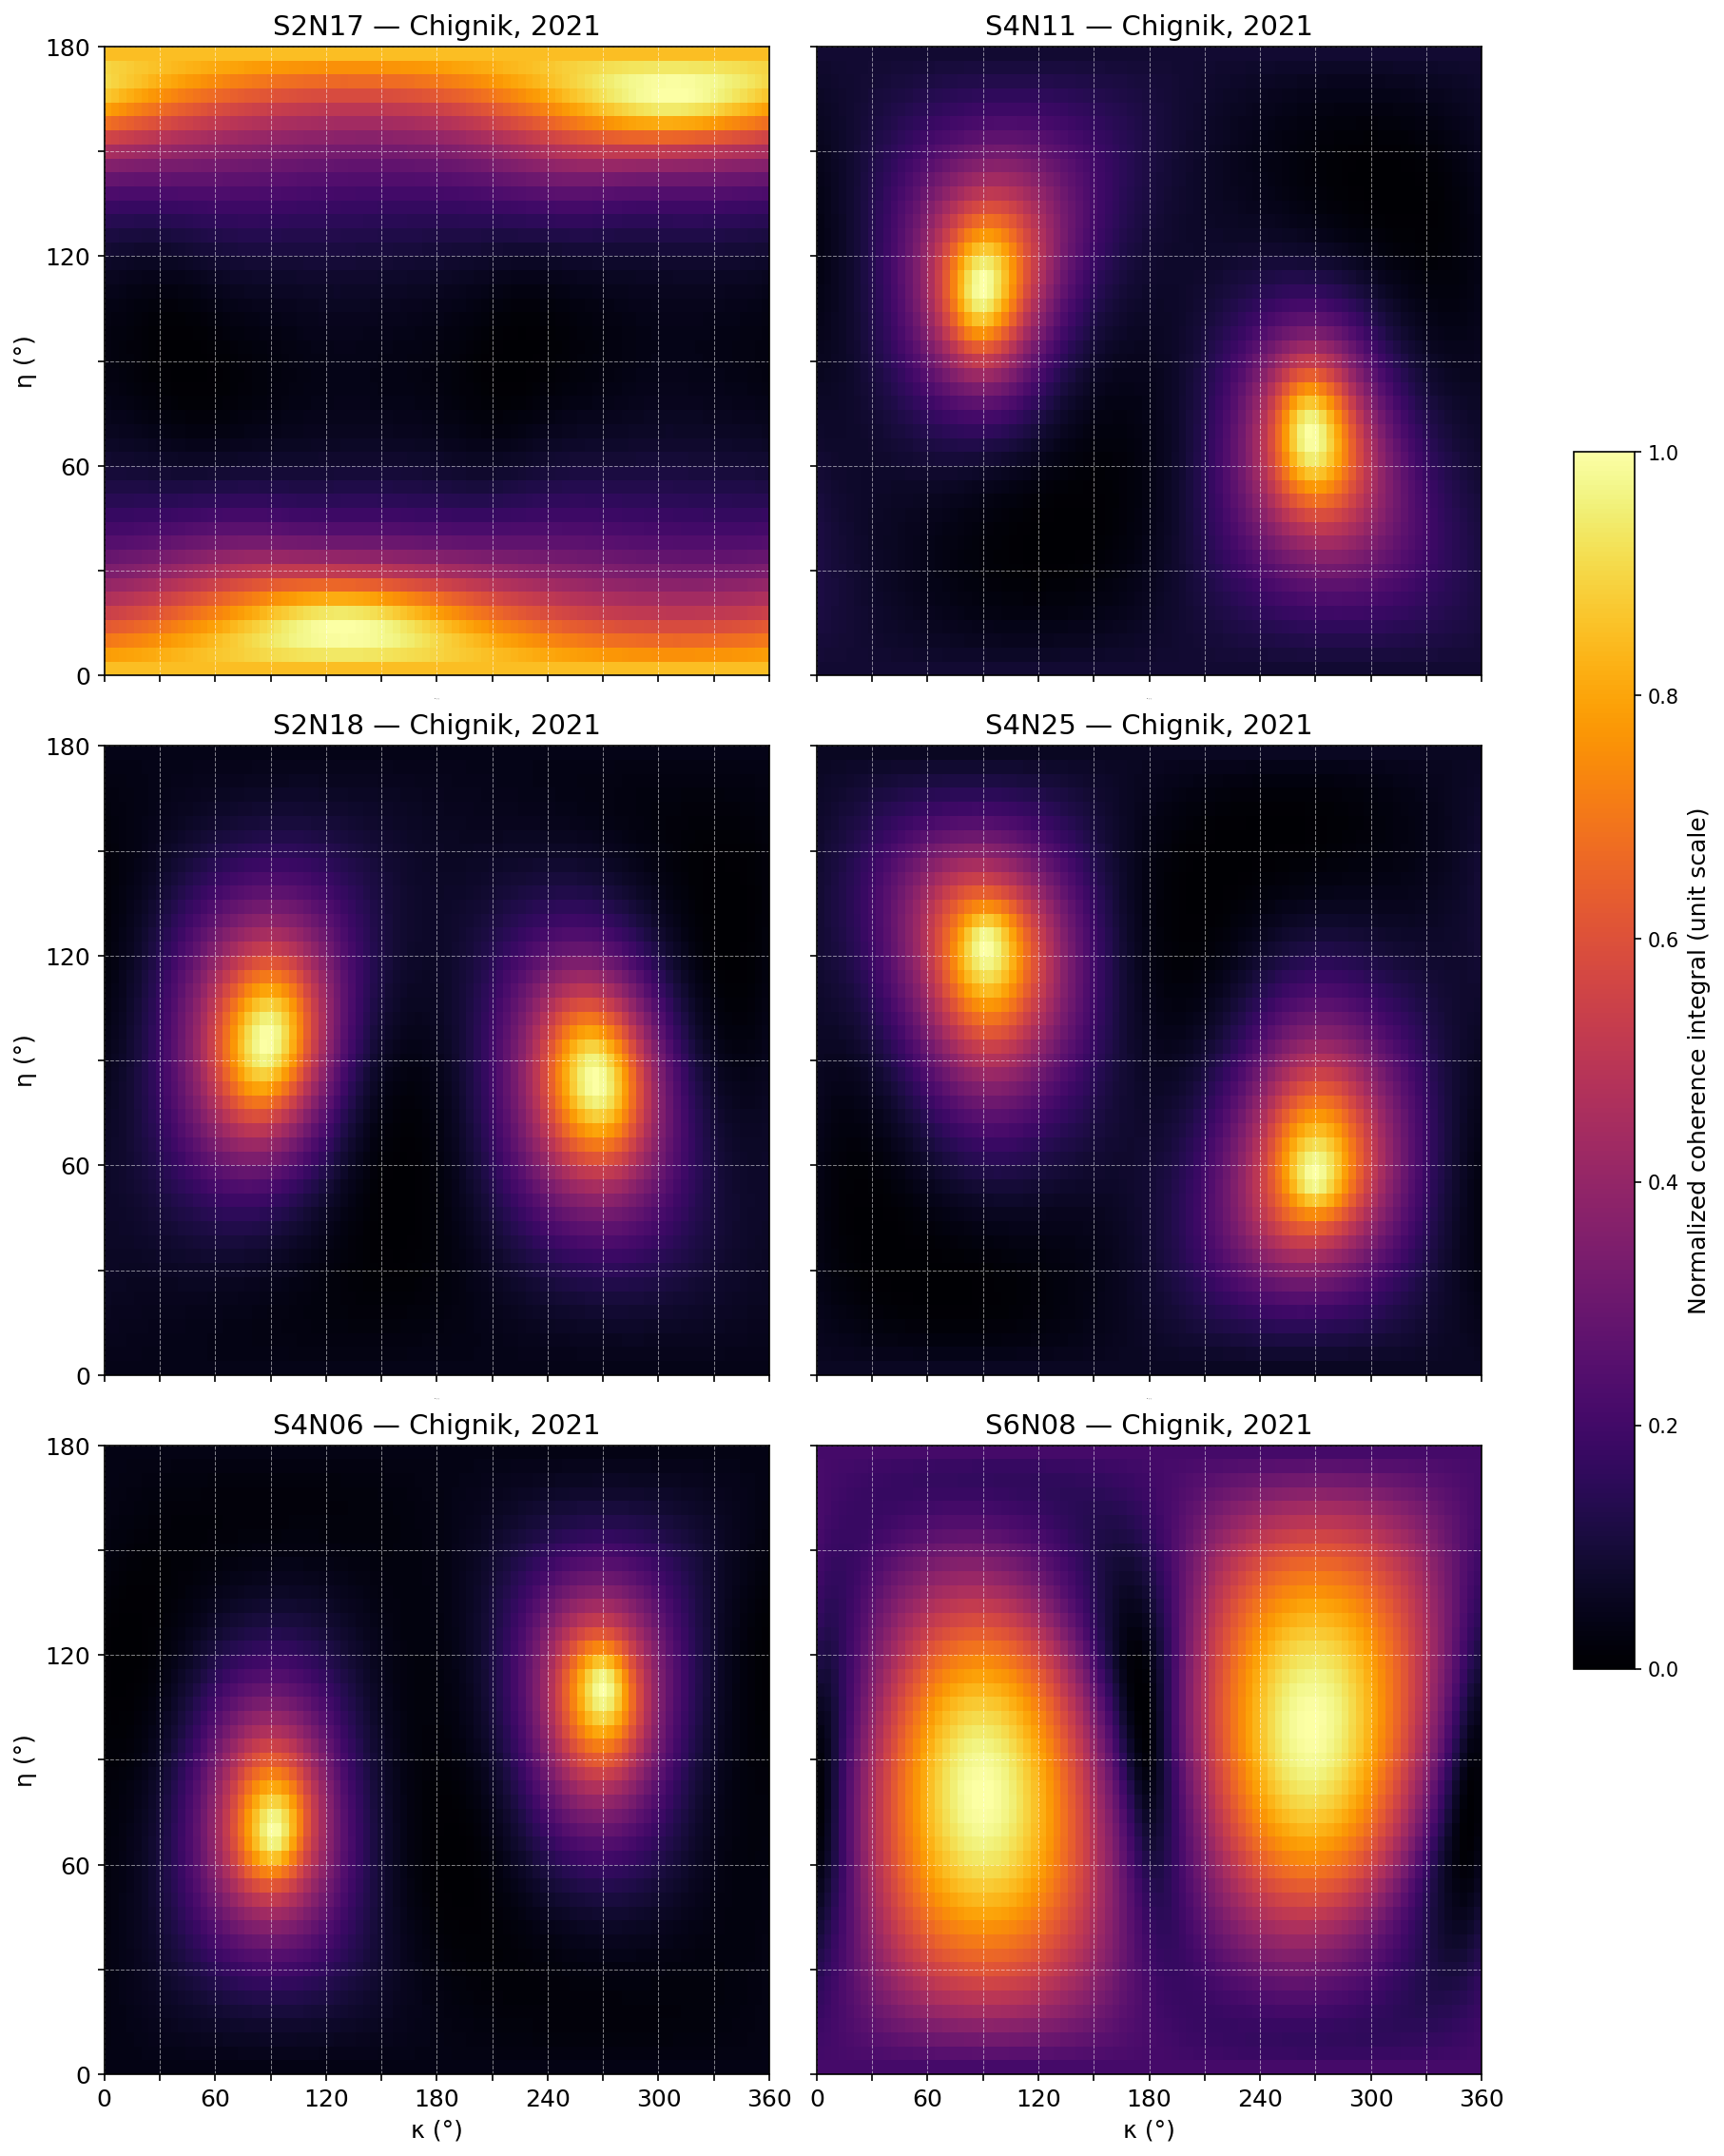

Execution time: 651.56 seconds
Saved: event3_grid.png


In [3]:
import time

from google.colab import drive
drive.mount('/content/drive')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.fftpack as fp
from scipy import signal
import math
start_time = time.time()
nperseg = 2**13
samplelen = 71999

stations = [
    [r'\S2N17', 'e30e', 'e302', '2247', '0.04893', '0.04792', '0.04923', 'e300', 'e301'],
    [r'\S2N18', 'e31e', 'e312', '2460', '0.04878', '0.04930', '0.04885', 'e310', 'e311'],
    [r'\S4N06', 'e65c', 'e652', '1970', '0.04874', '0.04863', '0.04856', 'e650', 'e651'],
    [r'\S4N11', 'e6ae', 'e6a2', '2273', '0.04829', '0.04818', '0.04912', 'e6a0', 'e6a1'],
    [r'\S4N25', 'e78e', 'e782', '2228', '0.04792', '0.04811', '0.04729', 'e780', 'e781'],
    [r'\S6N08', 'ea7e', 'ea72', '5900', '0.05205', '0.05182', '0.05178', 'ea70', 'ea71'],
]

eventsp = [
    r'/content/drive/MyDrive/data/pressure/Noto/',
    r'/content/drive/MyDrive/data/pressure/Gulf/',
    r'/content/drive/MyDrive/data/pressure/Kamchatka/',
    r'/content/drive/MyDrive/data/pressure/Chignik/'
]
eventsac = [
    r'/content/drive/MyDrive/data/acceleration/Noto/',
    r'/content/drive/MyDrive/data/acceleration/Gulf/',
    r'/content/drive/MyDrive/data/acceleration/Kamchatka/',
    r'/content/drive/MyDrive/data/acceleration/Chignik/'
]

# ----- configuration: index of the event to visualize -----
# 0,1,2, or 3 depending on eventsp/eventsac.
event_index = 3

# labels for events (change if needed)
event_title_map = {
    0: 'Noto, 2024',
    1: 'Gulf of Alaska, 2018',
    2: 'Kamchatka, 2025',
    3: 'Chignik, 2021'
}
event_title = event_title_map.get(event_index, f'Event {event_index}')

# Collect all b-matrices first (to normalize by a single scale)
b_list = []
station_names = []
valid_indices = []  # indices of stations for which data was successfully read

thetres = 45
phires = thetres*2
th = np.linspace(0, 180, thetres)
ph = np.linspace(0, 360, phires)

for idx, st in enumerate(stations):
    station_name = st[0][1:]  # without leading slash
    station_names.append(station_name)

    # paths to files for the selected event
    pres_path = eventsp[event_index] + st[1] + '.dat'
    acc_vert_path = eventsac[event_index] + st[2] + '.dat'
    acc_x_path = eventsac[event_index] + st[7] + '.dat'
    acc_y_path = eventsac[event_index] + st[8] + '.dat'

    # check if files exist
    if not (os.path.exists(pres_path) and os.path.exists(acc_vert_path) and os.path.exists(acc_x_path) and os.path.exists(acc_y_path)):
        print(f"Warning: skipping station {station_name} (some files not found).")
        b_list.append(None)
        continue

    try:
        data = pd.read_csv(pres_path, delimiter='\t') / 14.0
        data2 = pd.read_csv(acc_vert_path, delimiter='\t') / float(st[4]) * 4.377e-7
        datax = pd.read_csv(acc_x_path, delimiter='\t') / float(st[5]) * 4.377e-7
        datay = pd.read_csv(acc_y_path, delimiter='\t') / float(st[6]) * 4.377e-7
    except Exception as e:
        print(f"Error reading files for {station_name}: {e}")
        b_list.append(None)
        continue

    # resample, detrend
    data2 = signal.resample(data2, (len(data2)+1)//10 - 1)
    data2 = signal.detrend(data2, axis=0)
    datax = signal.resample(datax, (len(datax)+1)//10 - 1)
    datax = signal.detrend(datax, axis=0)
    datay = signal.resample(datay, (len(datay)+1)//10 - 1)
    datay = signal.detrend(datay, axis=0)

    # truncate by length
    data2 = np.asarray(data2).flatten()[17500:].copy()
    datax = np.asarray(datax).flatten()[17500:].copy()
    datay = np.asarray(datay).flatten()[17500:].copy()

    # prepare pressure data
    x = np.linspace(0, len(data), num=len(data)+1)
    x = x[:-1]
    data = data[17500:].copy()
    x = x[17500:].copy()

    model = np.polyfit(x, data.to_numpy().flatten(), 8)
    predicted = np.polyval(model, x)
    data_arr = data.T.to_numpy()[0]
    data_arr = data_arr - predicted
    data_arr = np.asarray(data_arr).flatten()

    # compute b matrix
    b = np.zeros((thetres, phires))
    for ii, theta in enumerate(th):
        cos_t = math.cos(theta * math.pi / 180.0)
        sin_t = math.sin(theta * math.pi / 180.0)
        for jj, phi in enumerate(ph):
            # combined signal by angles
            truez = (data2 * cos_t +
                     datay * sin_t * math.sin(phi * math.pi / 180.0) +
                     datax * sin_t * math.cos(phi * math.pi / 180.0))
            # coherence signal
            try:
                xwelch, welch = signal.coherence(data_arr, truez, fs=10, nperseg=nperseg, axis=0)
            except Exception as e:
                # for short series, etc.
                welch = np.zeros(1)
                xwelch = np.array([0.])
            # integral over selected frequency range
            fmin = 0.366 * math.sqrt(9.8 / float(st[3]))
            fmax = max(0.1, 1500.0 / (4.0 * float(st[3])))
            integral = 0.0
            for kf, val in zip(xwelch, welch):
                if fmin < kf < fmax:
                    integral += abs(val)
            b[ii, jj] = integral

    b_list.append(b)
    valid_indices.append(idx)
    print(f"Computed b for station {station_name}")

# If no matrices were obtained — terminate
if all(b is None for b in b_list):
    raise RuntimeError("No data available for selected event/stations — check paths and files.")

# Find global min/max for normalization
valid_b = [b for b in b_list if b is not None]
global_min = min(np.min(b) for b in valid_b)
global_max = max(np.max(b) for b in valid_b)
if global_max == global_min:
    global_max = global_min + 1e-12  # to avoid division by zero

# Create 3x2 figure
fig, axes = plt.subplots(3, 2, figsize=(12, 15), dpi=150, constrained_layout=True)

th_edges = np.linspace(0, 180, thetres + 1)
ph_edges = np.linspace(0, 360, phires + 1)

for idx, b in enumerate(b_list):
    col = idx // 3       # 0 or 1
    row = idx % 3        # 0,1,2
    ax = axes[row, col]

    if b is None:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(station_names[idx])
        continue

    # normalize by global scale
    b_min = np.min(b)
    b_max = np.max(b)
    if b_max == b_min:
        b_norm = np.zeros_like(b)  # if constant — show zeros
    else:
        b_norm = (b - b_min) / (b_max - b_min)
    im = ax.pcolormesh(ph_edges, th_edges, b_norm, cmap='inferno', vmin=0, vmax=1)

    # labels
    ax.set_title(f'{station_names[idx]} — {event_title}', fontsize=14)

    if col == 0:
        yticks = np.arange(0, 181, 30)
        yticklabels = [str(y) if i % 2 == 0 else '' for i, y in enumerate(yticks)]
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=12)
    else:
        ax.set_yticks(np.arange(0, 181, 30))
        ax.set_yticklabels([])

    if row == 2:
        xticks = np.arange(0, 361, 30)
        xticklabels = [str(x) if i % 2 == 0 else '' for i, x in enumerate(xticks)]
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, fontsize=12)
    else:
        ax.set_xticks(np.arange(0, 361, 30))
        ax.set_xticklabels([])

    ax.set_xlabel('κ (°)', fontsize=12 if row==2 else 0)
    ax.set_ylabel('η (°)' if col==0 else '', fontsize=12 if col==0 else 0)
    ax.grid(visible=True, which='major', color='white', linestyle='--', linewidth=0.5, alpha=0.5)

# Common colorbar
cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.6)
cbar.set_label('Normalized coherence integral (unit scale)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

out_fname = r'event{}_grid.png'.format(event_index)
plt.savefig(out_fname)
plt.show()

end_time = time.time()
print(f"Execution time: {end_time - start_time:.2f} seconds")
print(f"Saved: {out_fname}")